# Regression Trees & Random Forest Regression

## Libraries and settings

In [1]:
# Libraries
import os
import numpy as np
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

/Users/rodion/Desktop/ZHAW/data_analytics/Week_08


## Import the apartment data

In [2]:
# Define columns for import
columns = [ 'web-scraper-order',
            'address_raw',
            'rooms',
            'area',
            'luxurious',
            'price',
            'price_per_m2',
            'lat',
            'lon',
            'bfs_number',
            'bfs_name',
            'pop',
            'pop_dens',
            'frg_pct',
            'emp',
            'mean_taxable_income',
            'dist_supermarket']

# Read and select variables
df_orig = pd.read_csv("apartments_data_enriched_cleaned.csv", sep=";", encoding='utf-8')[columns]

# Rename variable 'web-scraper-order' to 'apmt_id'
df_orig = df_orig.rename(columns={'web-scraper-order': 'id'})

# Remove missing values
df = df_orig.dropna()
df.head(5)

# Remove duplicates
df = df.drop_duplicates()

# Remove some 'extreme' values
df = df.loc[(df['price'] >= 1000) & 
            (df['price'] <= 5000)]

# Reset index
df = df.reset_index(drop=True)

print(df.shape)
df.head(5)

(722, 17)


,id,address_raw,rooms,area,luxurious,price,price_per_m2,lat,lon,bfs_number,bfs_name,pop,pop_dens,frg_pct,emp,mean_taxable_income,dist_supermarket
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",3.0,49,0,1441,29.41,47.252171,8.845797,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,645.652248
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",3.0,111,0,2600,23.42,47.252087,8.854919,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,265.102153
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",3.0,58,0,1490,25.69,47.253670,8.853993,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,94.401821
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",4.0,118,0,3240,27.46,47.259834,8.851705,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,106.660970
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",3.0,66,0,1450,21.97,47.266113,8.866872,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,974.844209


## Regression Tree
See also: https://data36.com/regression-tree-python-scikit-learn

### Create train and test samples for the regression tree (train = 80%, test = 20% of the data)

In [16]:
# Create train and test samples
X_train, X_test, y_train, y_test = train_test_split(df[[
                                                        # 'area', 
                                                        # 'rooms',
                                                        'pop_dens',
                                                        'mean_taxable_income',
                                                        'dist_supermarket']], 
                                                        df['price'], 
                                                        test_size=0.20, 
                                                        random_state=42)

# Show X_train
print('X_train:')
print(X_train.head(), '\n')

# Show y_train
print('y_train:')
print(y_train.head())

X_train:
        pop_dens  mean_taxable_income  dist_supermarket
456   165.018625          65380.98802       1958.318650
6     525.662252         111422.35870        282.095910
362   424.146342          72133.75058       2606.231069
594  1044.628957          70964.08794        564.607066
439   399.525129          62000.54187        646.823905 

y_train:
456    1900
6      1850
362    2090
594    2102
439    1800
Name: price, dtype: int64


### Fit the regression tree model

In [17]:
# Create decision tree regressor object
reg = DecisionTreeRegressor(random_state=20, max_depth=5)

# Train decision tree regressor
reg = reg.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = reg.predict(X_test)

### Calculate coefficient of determination (R-squared)

In [18]:
# Calculate coefficient of determination, round to 4 decimals
print(f'R-squared:, {r2_score(y_test, y_pred):.4f}')

R-squared:, 0.0192


## Task 2

### C)


When the variables `area` and `rooms` are dropped from the train and test samples, the R-squared value changes significantly, dropping from 0.5247 to 0.0192. This happens because these two variables are likely highly predictive of the target variable `price`. By removing them, the model loses important information that helps explain the variance in the target variable. As a result, the model's ability to make accurate predictions decreases, leading to a much lower R-squared value.

R-squared measures the proportion of variance in the dependent variable that is predictable from the independent variables. Removing key predictors reduces the model's explanatory power, which is reflected in the lower R-squared value.

### Print text representation of the regression tree

In [19]:
# Text representation of the regression tree
text_representation = tree.export_text(reg, 
                                       feature_names=list(X_train.columns))

# Print text_representation
print(text_representation)

|--- mean_taxable_income <= 79509.47
|   |--- dist_supermarket <= 864.63
|   |   |--- dist_supermarket <= 521.88
|   |   |   |--- dist_supermarket <= 515.60
|   |   |   |   |--- pop_dens <= 1357.61
|   |   |   |   |   |--- value: [2278.18]
|   |   |   |   |--- pop_dens >  1357.61
|   |   |   |   |   |--- value: [2108.95]
|   |   |   |--- dist_supermarket >  515.60
|   |   |   |   |--- value: [3440.00]
|   |   |--- dist_supermarket >  521.88
|   |   |   |--- pop_dens <= 1471.94
|   |   |   |   |--- pop_dens <= 770.16
|   |   |   |   |   |--- value: [2165.35]
|   |   |   |   |--- pop_dens >  770.16
|   |   |   |   |   |--- value: [1827.62]
|   |   |   |--- pop_dens >  1471.94
|   |   |   |   |--- mean_taxable_income <= 77949.16
|   |   |   |   |   |--- value: [2236.94]
|   |   |   |   |--- mean_taxable_income >  77949.16
|   |   |   |   |   |--- value: [2940.00]
|   |--- dist_supermarket >  864.63
|   |   |--- mean_taxable_income <= 71756.05
|   |   |   |--- mean_taxable_income <= 65012.

### Vizualizing the regression tree

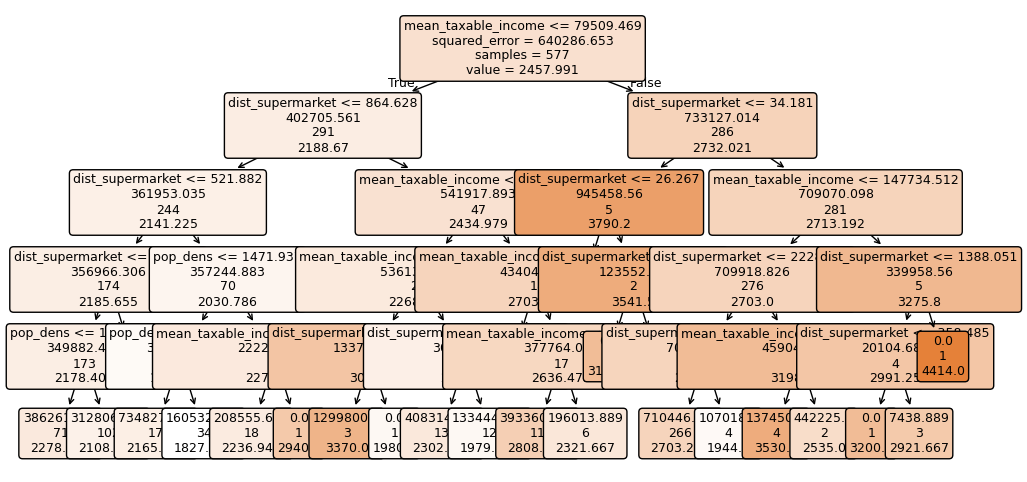

In [20]:
fig = plt.figure(figsize=(12,6))
_ = tree.plot_tree(reg, 
                   feature_names=list(X_train.columns),  
                   class_names=['price'],
                   filled=True,
                   fontsize=9,
                   label='root',
                   rounded=True)

## Task 2

### B)

The differences in the output (text and graphic) are due to the increased complexity of the tree when `max_depth` is set to 5. A deeper tree can capture more patterns in the data, but it may also lead to overfitting, especially if the dataset is small or noisy. On the other hand, a shallower tree (e.g., `max_depth=3`) may underfit the data, failing to capture important patterns.

In practice, the choice of `max_depth` should balance the trade-off between underfitting and overfitting. This can be achieved by evaluating the model's performance on both the training and test datasets and using techniques like cross-validation to select the optimal depth.

## Random Forest Regression
For details see: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

### Create train and test samples for the random forest (train = 80%, test = 20% of the data)

In [21]:
# Create train and test samples (the names X2_ and y2_ were used because X_ and y_ were already used above)
X2_train, X2_test, y2_train, y2_test = train_test_split(df[[
                                                            # 'area', 
                                                            'rooms',
                                                            'pop_dens',
                                                            'mean_taxable_income',
                                                            'dist_supermarket']], 
                                                            df['price'], 
                                                            test_size=0.20, 
                                                            random_state=42)

# Show X2_train
print('X2_train:')
print(X2_train.head(), '\n')

# Show y2_train
print('y2_train:')
print(y2_train.head())

X2_train:
     rooms     pop_dens  mean_taxable_income  dist_supermarket
456    6.5   165.018625          65380.98802       1958.318650
6      3.5   525.662252         111422.35870        282.095910
362    3.5   424.146342          72133.75058       2606.231069
594    2.5  1044.628957          70964.08794        564.607066
439    3.5   399.525129          62000.54187        646.823905 

y2_train:
456    1900
6      1850
362    2090
594    2102
439    1800
Name: price, dtype: int64


### Fit the Random Forest Regression

In [22]:
X, y = make_regression(n_features=4, n_informative=2,
                       random_state=5, shuffle=False)


reg_rf = RandomForestRegressor(n_estimators=500, 
                               max_depth=10, 
                               random_state=5)
reg_rf.fit(X2_train, y2_train)

# Calculate coefficient of determination (R-squared)
print(f'R-squared: {reg_rf.score(X2_test, y2_test):.4f}')

R-squared: 0.3215


### Show feature importance

Index(['rooms', 'dist_supermarket', 'mean_taxable_income', 'pop_dens'], dtype='object')
[0.39736226 0.27042968 0.17860647 0.15360159]


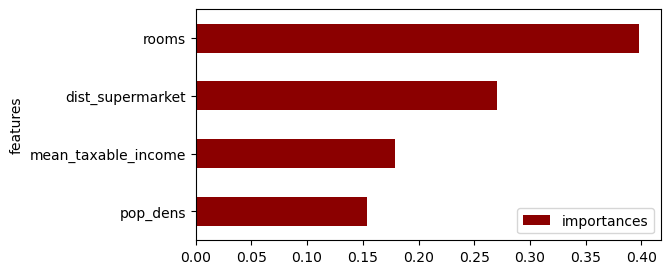

In [24]:
cols = X2_train.columns

# Derive feature importance from random forest
importances = reg_rf.feature_importances_
std         = np.std([tree.feature_importances_ for tree in reg_rf.estimators_], axis=0)
indices     = np.argsort(importances)[::-1]

# Print col-names and importances-values
print( cols[indices] )
print( importances[indices] )

# Barplot with feature importance
df_fi = pd.DataFrame({'features':cols,'importances': importances})
df_fi.sort_values('importances', inplace=True)
df_fi.plot(kind='barh', 
           y='importances', 
           x='features', 
           color='darkred', 
           figsize=(6,3))

plt.show()

## Task 2

### F)

If the importance of features changes after dropping `area`, it is because the model redistributes the importance among the remaining features. The `area` variable might have been highly predictive of the target variable, and without it, the model relies more heavily on the remaining features (`rooms`, `pop_dens`, `mean_taxable_income`, and `dist_supermarket`) to make predictions. This redistribution of importance reflects the model's adaptation to the available data.

Feature importance in random forests is calculated based on how much each feature contributes to reducing the impurity (e.g., Gini impurity or variance) in the decision trees. When a key feature is removed, the contribution of other features may increase to compensate for the missing information.

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [25]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 24.6.0
Datetime: 2025-12-04 13:07:43
Python Version: 3.10.15
-----------------------------------
